In [1]:
!pip -q install huggingface_hub gradio pandas matplotlib openpyxl python-docx PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.4 MB/s eta 0:00:00


In [2]:
import os
import io
import json

import pandas as pd
import matplotlib.pyplot as plt

import gradio as gr

import PyPDF2
from docx import Document

from huggingface_hub import login, InferenceClient

In [3]:
login()
client = InferenceClient()


In [4]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

In [5]:
def generate_business_email(
    purpose,
    recipient_name,
    tone,
    key_points
):
    """
    Generates a professional business email using the LLM.
    Returns:
        subject
        email_body
    """

    prompt = f"""
You are an expert business communication assistant.

Write a professional email.

Purpose:
{purpose}

Recipient:
{recipient_name}

Tone:
{tone}

Important Points:
{key_points}

Return your response EXACTLY in this format:

Subject:
<email subject>

Body:
<professional email body>

Do not include any explanations.
"""

    response = client.chat_completion(

        model=MODEL_NAME,

        messages=[
            {
                "role": "system",
                "content": "You are a professional business email assistant."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        max_tokens=600,
        temperature=0.5
    )

    email_text = response.choices[0].message.content.strip()

    subject = ""
    body = ""

    if "Body:" in email_text:

        parts = email_text.split("Body:")

        subject = (
            parts[0]
            .replace("Subject:", "")
            .strip()
        )

        body = parts[1].strip()

    else:

        body = email_text

    return subject, body

In [6]:
subject, body = generate_business_email(

    purpose="Follow-up after a Machine Learning internship interview",

    recipient_name="Hiring Manager",

    tone="Professional and Polite",

    key_points="""
Thank them for their time.
Mention your enthusiasm for the role.
Reiterate your interest.
Offer to provide any additional information.
"""
)

print("Subject:")
print(subject)

print("\n")

print(body)

Subject:
Follow-Up on Machine Learning Internship Interview


Dear [Hiring Manager's Name],

I hope this email finds you well. I wanted to extend my gratitude for taking the time to interview me for the Machine Learning internship position. I am very enthusiastic about the opportunity to contribute to your team and am excited about the potential to work on cutting-edge projects.

I remain very interested in the role and would be happy to provide any additional information or documentation that may be required. Please do not hesitate to contact me if you need any further details from my end.

Thank you once again for considering my application.

Best regards,
[Your Full Name]
[Your Contact Information]


In [7]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart


def send_email(
    sender_email,
    app_password,
    recipient_email,
    subject,
    body
):
    """
    Sends an email using Gmail SMTP.
    """

    try:

        message = MIMEMultipart()

        message["From"] = sender_email
        message["To"] = recipient_email
        message["Subject"] = subject

        message.attach(
            MIMEText(body, "plain")
        )

        with smtplib.SMTP("smtp.gmail.com", 587) as server:

            server.starttls()

            server.login(
                sender_email,
                app_password
            )

            server.send_message(message)

        return "✅ Email sent successfully!"

    except Exception as e:

        return f"❌ Error: {str(e)}"

In [9]:
status = send_email(

    sender_email="venayamulani1630@gmail.com",

    app_password="cjep aind gpzv hgjz",

    recipient_email="24dcs043@lnmiit.ac.in",

    subject=subject,

    body=body
)

print(status)

✅ Email sent successfully!


In [11]:
import PyPDF2
from docx import Document


def extract_text(file):

    if file is None:
        return ""

    filename = file.name.lower()

    if filename.endswith(".pdf"):

        text = ""

        with open(file.name, "rb") as f:

            reader = PyPDF2.PdfReader(f)

            for page in reader.pages:

                page_text = page.extract_text()

                if page_text:
                    text += page_text + "\n"

        return text.strip()

    elif filename.endswith(".docx"):

        doc = Document(file.name)

        text = "\n".join(
            para.text for para in doc.paragraphs
        )

        return text.strip()


    elif filename.endswith(".txt"):

        with open(file.name, "r", encoding="utf-8") as f:

            return f.read()

    else:

        return "Unsupported file format."

In [12]:
from google.colab import files

uploaded = files.upload()

file_path = list(uploaded.keys())[0]

class UploadedFile:
    def __init__(self, name):
        self.name = name

sample_file = UploadedFile(file_path)

document_text = extract_text(sample_file)

print(document_text[:2000])

Saving MITRA_Solution_Approach.pdf to MITRA_Solution_Approach.pdf
MITRA - Mule Intelligence and Triage for Rightful Action
Solution Approach - PSB's Cybersecurity, Fraud and Artificial Intelligence Hackathon 2026
Organised by Bank of India in collaboration with IIT Hyderabad
Problem Statement Selected
Problem Statement 2: Developing a solution having AI/ML capabilities for detecting suspicious
transactions and mule accounts by ingesting financial transactions and/or fraud monitoring solution
alerts and /or Transaction monitoring system alerts and govt cyber fraud alerts/tickets and
preventing circulation of fraudulent proceeds through mule accounts. This solution should consume
real-time regulatory inputs/feeds and cross-channel bank data.
The Real Problem We Are Solving
India lost over Rs 22,495 crore to cyber fraud in 2025. To fight back, agencies have been freezing
mule accounts at a massive scale. Between September 2024 and January 2026 alone, more than 27
lakh suspected mule accou

In [13]:
def summarize_business_report(document_text):

    if len(document_text.strip()) == 0:
        return "No document text found."

    document_text = document_text[:6000]

    prompt = f"""
You are a senior business analyst.

Read the following business document and generate a structured report.

Business Document:

{document_text}

Generate the response using the following format:

## Executive Summary

## Key Takeaways

## Action Items

## Business Recommendations

Keep the response professional and concise.
"""

    response = client.chat_completion(

        model=MODEL_NAME,

        messages=[
            {
                "role": "system",
                "content": "You are an expert business analyst."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        max_tokens=1000,
        temperature=0.4

    )

    return response.choices[0].message.content

In [14]:
summary = summarize_business_report(document_text)

print(summary)

## Executive Summary

MITRA (Mule Intelligence and Triage for Rightful Action) is a sophisticated AI/ML solution designed to address the issue of false positives in mule account detection, which has led to the freezing of innocent accounts. The solution leverages a multi-layered approach to provide a nuanced decision-making process, ensuring that fraud officers can take proportionate and legally grounded actions. MITRA integrates real-time data from various sources, including financial transactions, government alerts, and cross-channel bank data, to generate detailed risk and innocence scores. These scores are then processed by a decision engine that provides tailored legal responses, thereby minimizing the impact on innocent account holders while effectively combating fraud.

## Key Takeaways

1. **Multi-Layered Decision-Making**: MITRA uses three layers (NYAY Scoring Engine, TULA Decision Engine, and Plain Language Explanation) to provide a comprehensive and legally sound approach to

In [15]:
import matplotlib.pyplot as plt


def analyze_business_csv(csv_file):

    df = pd.read_csv(csv_file.name)

    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    if len(numeric_cols) == 0:
        return df, "No numeric columns found.", None

    report = []

    report.append(f"Total Rows : {len(df)}")
    report.append(f"Total Columns : {len(df.columns)}")

    for col in numeric_cols:

        report.append(f"\n📊 {col}")

        report.append(f"Mean : {df[col].mean():.2f}")
        report.append(f"Median : {df[col].median():.2f}")
        report.append(f"Minimum : {df[col].min():.2f}")
        report.append(f"Maximum : {df[col].max():.2f}")
        report.append(f"Total : {df[col].sum():.2f}")

    plt.figure(figsize=(8,5))

    df[numeric_cols].sum().plot(
        kind="bar"
    )

    plt.title("Business Metrics Overview")

    plt.ylabel("Value")

    plt.tight_layout()

    chart_path = "business_metrics.png"

    plt.savefig(chart_path)

    plt.close()

    return df, "\n".join(report), chart_path

Saving emails.csv to emails.csv
Total Rows : 5728
Total Columns : 2

📊 spam
Mean : 0.24
Median : 0.00
Minimum : 0.00
Maximum : 1.00
Total : 1368.00


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


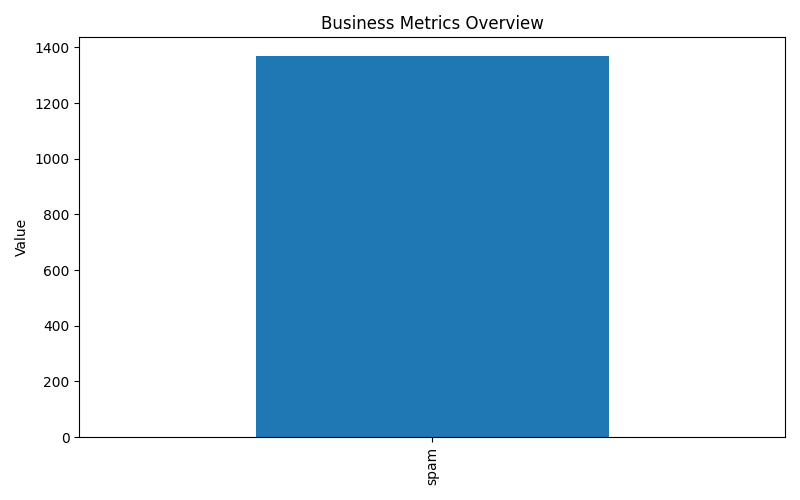

In [16]:
from google.colab import files

uploaded = files.upload()

csv_path = list(uploaded.keys())[0]

class UploadedCSV:
    def __init__(self, name):
        self.name = name

sample_csv = UploadedCSV(csv_path)

dataframe, stats, chart = analyze_business_csv(sample_csv)

print(stats)

display(dataframe.head())

from IPython.display import Image
Image(chart)

In [17]:
def generate_business_insights(statistics):

    prompt = f"""
You are an experienced Business Consultant.

Below are statistics generated from a company's business dataset.

Business Statistics

{statistics}

Your task is to prepare a professional report.

Generate your response using the following sections:

## Executive Summary

## Business Insights

- Identify important patterns.
- Mention unusual values if any.
- Explain what these statistics indicate.

## Risks

Mention possible business risks.

## Recommendations

Provide practical business recommendations.

## Next Steps

Suggest 3-5 actionable steps management should take.

Keep the report concise, professional and suitable for executives.
"""

    response = client.chat_completion(

        model=MODEL_NAME,

        messages=[
            {
                "role": "system",
                "content": "You are a senior business consultant."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        max_tokens=900,

        temperature=0.4

    )

    return response.choices[0].message.content

In [18]:
business_report = generate_business_insights(stats)

print(business_report)

## Executive Summary

The dataset provided contains 5,728 rows and 2 columns, with one of the columns labeled "spam." The spam column indicates whether a message is spam (1) or not (0). The statistical analysis reveals that 24.5% of the messages are spam, with a mean of 0.24, median of 0.00, minimum of 0.00, and maximum of 1.00. The total number of spam messages is 1,368. This report will provide business insights, identify potential risks, and offer recommendations to mitigate these risks.

## Business Insights

- **Important Patterns:**
  - The dataset is imbalanced, with a significant majority (75.5%) of the messages being non-spam.
  - The mean spam rate of 0.24 indicates that, on average, 24.5% of the messages are spam, which is a notable proportion.

- **Unusual Values:**
  - The median value of 0.00 suggests that the majority of the messages are classified as non-spam (0).
  - The minimum and maximum values of 0.00 and 1.00, respectively, confirm that the spam column is binary, 

In [ ]:
# ==========================================
# Business Automation Agent UI
# ==========================================

def email_workflow(
    sender_email,
    app_password,
    recipient_email,
    recipient_name,
    purpose,
    tone,
    key_points
):

    subject, body = generate_business_email(
        purpose,
        recipient_name,
        tone,
        key_points
    )

    status = send_email(
        sender_email,
        app_password,
        recipient_email,
        subject,
        body
    )

    return subject, body, status


def report_workflow(file):

    text = extract_text(file)

    return summarize_business_report(text)


def csv_workflow(file):

    df, stats, chart = analyze_business_csv(file)

    insights = generate_business_insights(stats)

    return (
        df,
        stats,
        chart,
        insights
    )


theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="slate"
)


with gr.Blocks(
    theme=theme,
    title="AI Business Automation Agent"
) as demo:

    gr.Markdown(
        """
        # 💼 AI Business Automation Agent

        Automate Emails • Summarize Reports • Generate Business Insights
        """
    )

    with gr.Tabs():

        # ------------------------------------------------

        with gr.Tab("📧 Email Automation"):

            sender_email = gr.Textbox(
                label="Sender Gmail"
            )

            app_password = gr.Textbox(
                label="Gmail App Password",
                type="password"
            )

            recipient_email = gr.Textbox(
                label="Recipient Email"
            )

            recipient_name = gr.Textbox(
                label="Recipient Name"
            )

            purpose = gr.Textbox(
                label="Purpose"
            )

            tone = gr.Dropdown(
                [
                    "Professional",
                    "Friendly",
                    "Formal",
                    "Polite"
                ],
                value="Professional",
                label="Tone"
            )

            key_points = gr.Textbox(
                lines=6,
                label="Key Points"
            )

            email_btn = gr.Button(
                "Generate & Send Email"
            )

            email_subject = gr.Textbox(
                label="Subject"
            )

            email_body = gr.Textbox(
                lines=12,
                label="Generated Email"
            )

            email_status = gr.Textbox(
                label="Status"
            )

            email_btn.click(
                email_workflow,
                inputs=[
                    sender_email,
                    app_password,
                    recipient_email,
                    recipient_name,
                    purpose,
                    tone,
                    key_points
                ],
                outputs=[
                    email_subject,
                    email_body,
                    email_status
                ]
            )

        # ------------------------------------------------

        with gr.Tab("📄 Report Summarizer"):

            report_file = gr.File(
                label="Upload PDF / DOCX / TXT"
            )

            summarize_btn = gr.Button(
                "Summarize"
            )

            report_output = gr.Textbox(
                lines=20,
                label="Business Report"
            )

            summarize_btn.click(
                report_workflow,
                inputs=report_file,
                outputs=report_output
            )

        # ------------------------------------------------

        with gr.Tab("📊 Business Insights"):

            csv_file = gr.File(
                label="Upload Business CSV"
            )

            analyze_btn = gr.Button(
                "Analyze"
            )

            dataframe_output = gr.Dataframe(
                label="Dataset Preview"
            )

            stats_output = gr.Textbox(
                lines=12,
                label="Statistics"
            )

            chart_output = gr.Image(
                label="Business Chart"
            )

            insight_output = gr.Textbox(
                lines=18,
                label="AI Business Insights"
            )

            analyze_btn.click(
                csv_workflow,
                inputs=csv_file,
                outputs=[
                    dataframe_output,
                    stats_output,
                    chart_output,
                    insight_output
                ]
            )


demo.launch(debug=True)

/tmp/ipykernel_998/3169113798.py:60: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2b8e2c74cb71c8ba66.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
